In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 524kB/s]

Extracting files...
Path to dataset files: C:\Users\uvang\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
df  = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [15]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [16]:
df = df.replace("male", 1)
df = df.replace("female", 0)

C:\Users\uvang\AppData\Local\Temp\ipykernel_15256\1710864422.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("female", 0)


In [17]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S
887,1,1,0,19.0,0,0,30.0000,S
888,0,3,0,NaN,1,2,23.4500,S
889,1,1,1,26.0,0,0,30.0000,C


In [22]:
def plot_data(X,y ,ax, pos_label="y=1" ,neg_label = "y=0", s=80, loc ="best"):
    pos = y ==1
    neg = y ==0
    pos = pos.reshape(-1,) 
    neg = neg.reshape(-1,)
    ax.scatter(X[pos, 0], X[pos, 1], marker ="x", s=s, c='red', label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker ="o", s=s, label=neg_label, facecolors='none', edgecolors="blue", lw=3)

y_train = np.array(df["Survived"][0:200])
y_train =y_train.reshape(-1, 1)


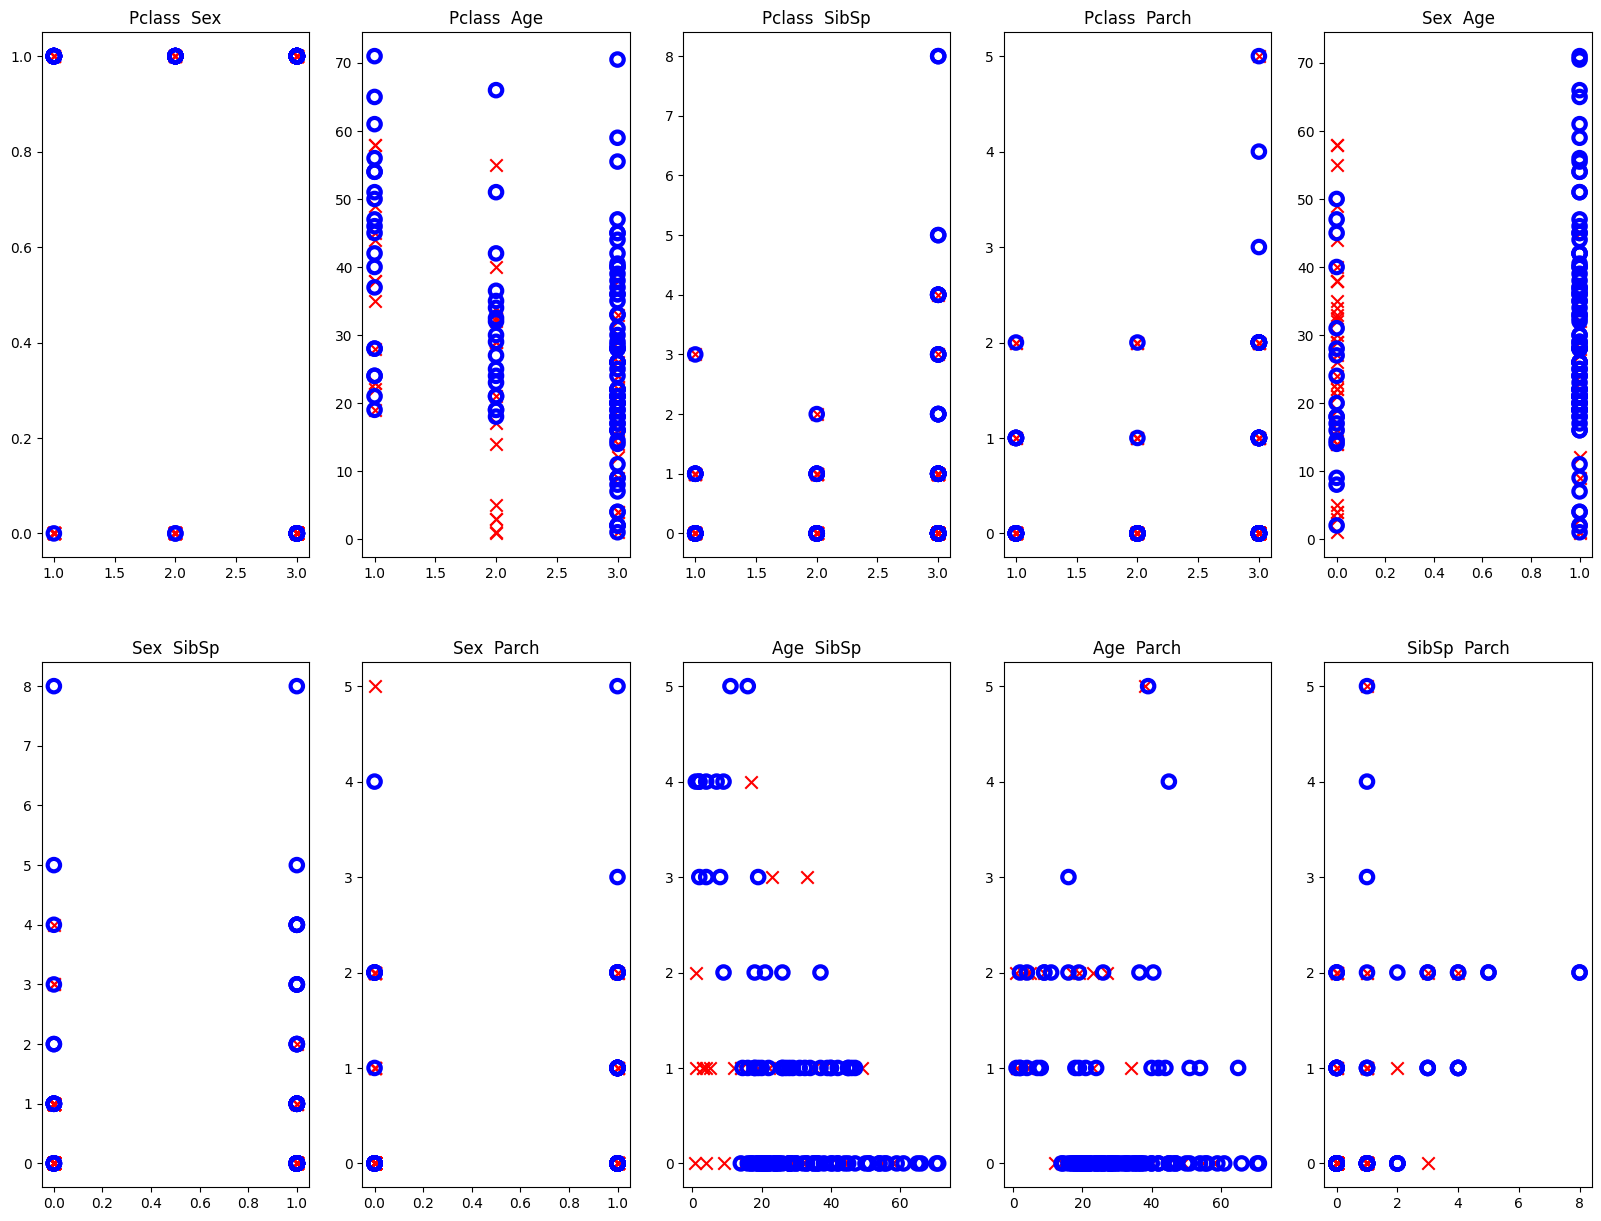

In [23]:
column_names = list(df.columns.values)
column_names = column_names[1:]
column_l = column_names.__len__()//5 + 1
fig,ax = plt.subplots(column_l,5,figsize=(20,15))
i,k = 0,0
num = 0
while(num < 5):
    for j in range(num +1, 5):
        x_train = np.array([df[column_names[num]][0:200],df[column_names[j]][0:200] ])
        x_train = np.column_stack((x_train[0], x_train[1]))
        plot_data(x_train, y_train, ax[i][k])
        ax[i][k].set_title(rf"{column_names[num]}  {column_names[j]}")
        if k == 4:
            k = 0
            i+=1
        else:
            k += 1
    num +=1

# Here we can use sex and age to create also an I
